In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from itertools import product

def find_repo_root(start=None):
    if start is None: start = Path.cwd().resolve()
    start = start.resolve()
    for path in [start] + list(start.parents):
        if (path / "src").exists() and (path / "DATA").exists(): return path
    raise FileNotFoundError("Could not find repo root.")

ROOT = find_repo_root()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
print(f"Project Root: {ROOT}")

pairs_path = ROOT / "results" / "training_window_data" / "tradable_pairs_by_window.csv"
pairs_matrix = pd.read_csv(pairs_path, index_col=0)
for col in pairs_matrix.columns:
    pairs_matrix[col] = pairs_matrix[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Stitch the timeline
regime_dir = ROOT / "results" / "testing_window_data"
regime_files = sorted(regime_dir.glob("regime_probabilities_*.csv"))
master_regimes = pd.concat([pd.read_csv(f) for f in regime_files], ignore_index=True)
master_regimes['test_date'] = pd.to_datetime(master_regimes['test_date'])
master_regimes = master_regimes.set_index('test_date').sort_index()
master_regimes = master_regimes[~master_regimes.index.duplicated(keep='last')]

Project Root: C:\Users\kiefe\OneDrive\Documents\GitHub\Cross-Country-Rates-Relative-Value-NUSInvest2526


In [ ]:
def optimize_thresholds_sharpe(df_train, entry_grid, exit_grid, cost_bps=5.0):
    best_sharpe = -np.inf
    best_params = (2.0, 0.5) # Default
    param_combinations = list(product(entry_grid, exit_grid))
    
    for entry_z, exit_z in param_combinations:
        long_setup = (df_train['innovation_z_t'] <= -entry_z).shift(1).fillna(False)
        short_setup = (df_train['innovation_z_t'] >= entry_z).shift(1).fillna(False)
        exit_setup = (df_train['innovation_z_t'].abs() <= exit_z).shift(1).fillna(False)
        
        positions = np.zeros(len(df_train))
        current_pos = 0
        
        for i in range(1, len(df_train)):
            if current_pos != 0 and exit_setup.iloc[i]:
                current_pos = 0
            elif current_pos == 0:
                if long_setup.iloc[i]: current_pos = 1
                elif short_setup.iloc[i]: current_pos = -1
            positions[i] = current_pos
            
        pos_series = pd.Series(positions, index=df_train.index)
        spread_diff = df_train['spread_t'].diff() * 10000
        trades_made = pos_series.diff().abs().fillna(0) > 0
        
        daily_pnl = ((pos_series.shift(1).fillna(0) * spread_diff) - (trades_made * cost_bps))
        
        # Calculate Annualized Sharpe
        std_dev = daily_pnl.std()
        if std_dev > 1e-6:
            sharpe = (daily_pnl.mean() / std_dev) * np.sqrt(252)
        else:
            sharpe = 0.0
            
        if sharpe > best_sharpe:
            best_sharpe = sharpe
            best_params = (entry_z, exit_z)
            
    return best_params

In [ ]:
def run_continuous_wf_backtest(pair_id, pairs_matrix, master_regimes, cost_bps=5.0):
    kalman_path = ROOT / "results" / "spreads" / f"{pair_id}.parquet"
    if not kalman_path.exists(): kalman_path = ROOT / "results" / "spreads" / f"{pair_id}_kalman.parquet"
    if not kalman_path.exists(): return pd.DataFrame()
            
    df = pd.read_parquet(kalman_path)
    df.index = pd.to_datetime(df['date'] if 'date' in df.columns else df.index)
    
    # 1. Map allowed regimes
    df = df.join(master_regimes[['regime_most_likely']], how='left')
    allowed_map = pairs_matrix[pair_id].to_dict()
    df['allowed_regimes'] = df.index.map(lambda d: allowed_map.get(f"{d.year}-01-01", []))
    df['regime_allowed'] = df.apply(
        lambda row: isinstance(row['allowed_regimes'], list) and row['regime_most_likely'] in row['allowed_regimes'], 
        axis=1
    )
    
    # 2. Generate dynamic parameters
    df['opt_entry_z'] = 2.0  
    df['opt_exit_z'] = 0.5   
    
    ENTRY_GRID = [1.5, 2.0, 2.5]
    EXIT_GRID = [0.0, 0.5, 1.0]
    
    for year in range(2010, 2026):
        train_end = f"{year-1}-12-31"
        df_train = df.loc[:train_end].copy()
        
        if len(df_train) > 500 and allowed_map.get(f"{year}-01-01", []):
            best_entry, best_exit = optimize_thresholds_sharpe(df_train, ENTRY_GRID, EXIT_GRID, cost_bps)
            year_mask = (df.index.year == year)
            df.loc[year_mask, 'opt_entry_z'] = best_entry
            df.loc[year_mask, 'opt_exit_z'] = best_exit

    # 3. T+1 signal generation
    df_test = df.loc['2010-01-01':].copy()
    
    df_test['long_setup'] = (df_test['innovation_z_t'] <= -df_test['opt_entry_z']).shift(1).fillna(False)
    df_test['short_setup'] = (df_test['innovation_z_t'] >= df_test['opt_entry_z']).shift(1).fillna(False)
    df_test['exit_setup'] = (df_test['innovation_z_t'].abs() <= df_test['opt_exit_z']).shift(1).fillna(False)
    df_test['forced_exit'] = (~df_test['regime_allowed']).shift(1).fillna(False)

    trade_log = []
    current_pos = 0
    entry_date, entry_price, entry_z_used, exit_z_used = None, 0, 0, 0
    
    for date, row in df_test.iterrows():
        # Exit Logic
        if current_pos != 0:
            exit_reason = None
            if row['exit_setup']: exit_reason = 'Mean Reversion'
            elif row['forced_exit']: exit_reason = 'Regime Shift (Forced)'
                
            if exit_reason:
                raw_pnl_bps = (row['spread_t'] - entry_price) * current_pos * 10000
                net_pnl_bps = raw_pnl_bps - cost_bps
                trade_log.append({
                    'Pair': pair_id, 'Entry Year': entry_date.year, 'Entry Date': entry_date,
                    'Exit Date': date, 'Direction': 'Long' if current_pos == 1 else 'Short',
                    'Entry Spread': entry_price, 'Exit Spread': row['spread_t'],
                    'Opt_Entry_Z': entry_z_used, 'Opt_Exit_Z': exit_z_used,
                    'Net PnL (bps)': net_pnl_bps, 'Holding Days': (date - entry_date).days,
                    'Exit Reason': exit_reason
                })
                current_pos = 0 
                
        # Entry Logic
        if current_pos == 0 and row['regime_allowed']:
            if row['long_setup']:
                current_pos = 1
                entry_date, entry_price = date, row['spread_t']
                entry_z_used, exit_z_used = row['opt_entry_z'], row['opt_exit_z']
            elif row['short_setup']:
                current_pos = -1
                entry_date, entry_price = date, row['spread_t']
                entry_z_used, exit_z_used = row['opt_entry_z'], row['opt_exit_z']
                
    # End of the 15-year dataset --> close trades
    if current_pos != 0:
        last_date = df_test.index[-1]
        raw_pnl_bps = (df_test['spread_t'].iloc[-1] - entry_price) * current_pos * 10000
        net_pnl_bps = raw_pnl_bps - cost_bps
        trade_log.append({
            'Pair': pair_id, 'Entry Year': entry_date.year, 'Entry Date': entry_date,
            'Exit Date': last_date, 'Direction': 'Long' if current_pos == 1 else 'Short',
            'Opt_Entry_Z': entry_z_used, 'Opt_Exit_Z': exit_z_used,
            'Net PnL (bps)': net_pnl_bps, 'Holding Days': (last_date - entry_date).days,
            'Exit Reason': 'End of Backtest (MTM)'
        })
                
    return pd.DataFrame(trade_log)

Running Sharpe-Optimized Walk-Forward Backtest... (This will take a minute)


C:\Users\kiefe\AppData\Local\Temp\ipykernel_23060\640193961.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  long_setup = (df_train['innovation_z_t'] <= -entry_z).shift(1).fillna(False)
C:\Users\kiefe\AppData\Local\Temp\ipykernel_23060\640193961.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  short_setup = (df_train['innovation_z_t'] >= entry_z).shift(1).fillna(False)
C:\Users\kiefe\AppData\Local\Temp\ipykernel_23060\640193961.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a futu


--- Trades Per Year ---


C:\Users\kiefe\AppData\Local\Temp\ipykernel_23060\3660963317.py:39: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['long_setup'] = (df_test['innovation_z_t'] <= -df_test['opt_entry_z']).shift(1).fillna(False)
C:\Users\kiefe\AppData\Local\Temp\ipykernel_23060\3660963317.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['short_setup'] = (df_test['innovation_z_t'] >= df_test['opt_entry_z']).shift(1).fillna(False)
C:\Users\kiefe\AppData\Local\Temp\ipykernel_23060\3660963317.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .

,Total Trades
Entry Year,
2010,1
2011,13
2012,5
2013,6
2014,5
2016,14
2017,4
2018,8
2019,7



--- Trades Per Pair ---


,Total Trades
Pair,
JPY-AUD 10Y,6
JPY-AUD 5Y,2
USD-EUR 10Y,60
USD-EUR 5Y,50


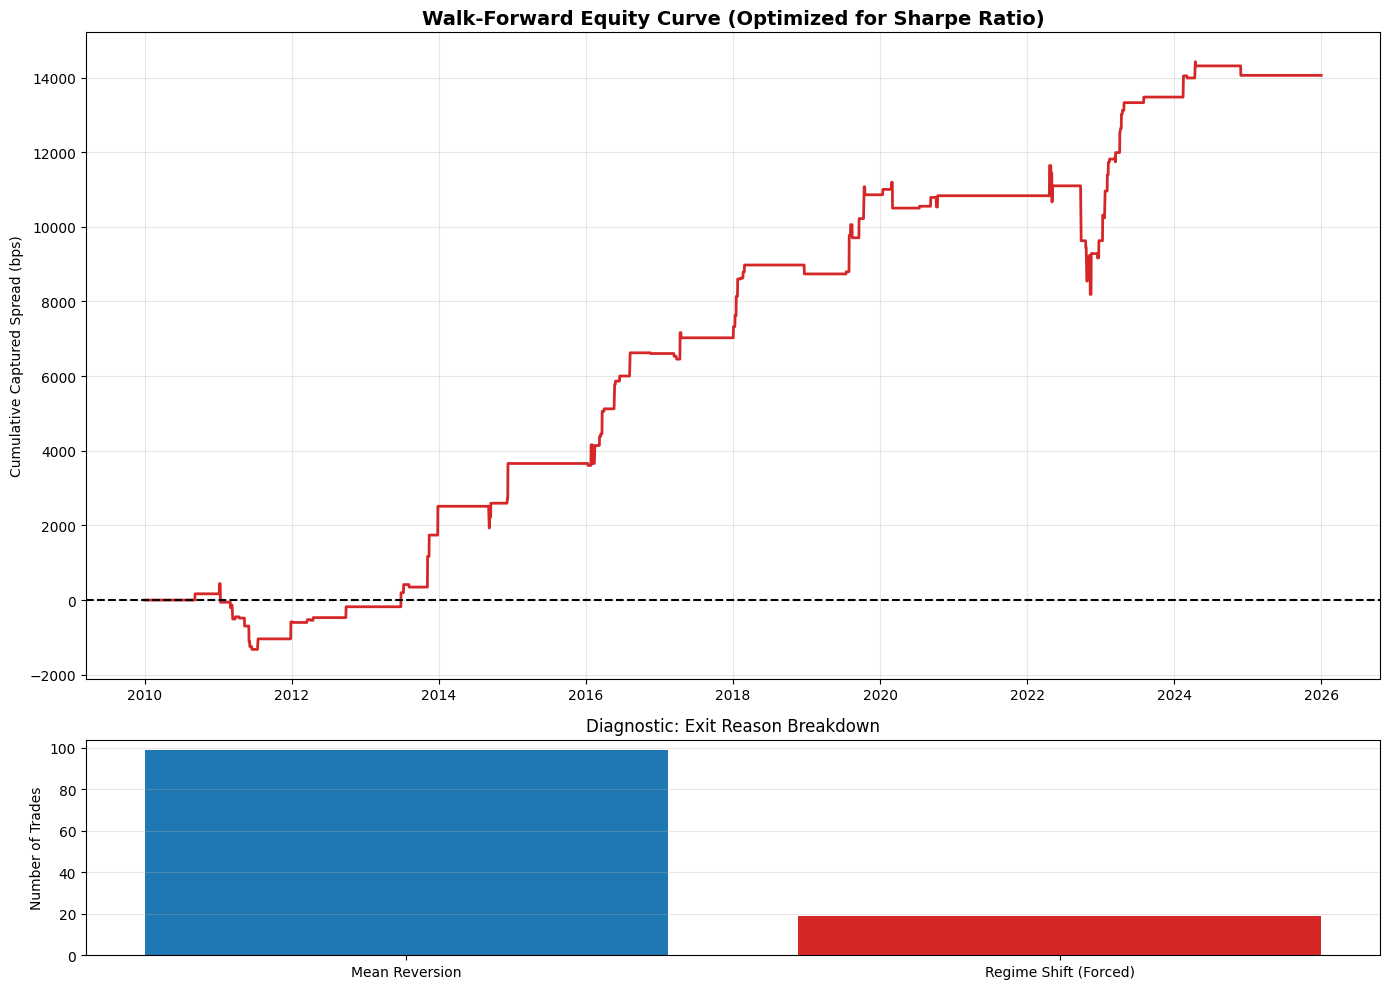

In [ ]:
all_pairs = pairs_matrix.columns.tolist()
all_trades = []

print("Running Sharpe-Optimized Walk-Forward Backtest... (This will take a minute)")

for pair in all_pairs:
    trades = run_continuous_wf_backtest(pair, pairs_matrix, master_regimes, cost_bps=5.0)
    if not trades.empty:
        all_trades.append(trades)

if not all_trades:
    raise ValueError("No trades generated across any pairs! Check logic/data.")

wf_ledger = pd.concat(all_trades, ignore_index=True)

# Diagnostic Tables
trades_per_year = wf_ledger.groupby('Entry Year').size().to_frame("Total Trades")
print("\n--- Trades Per Year ---")
display(trades_per_year)

trades_per_pair = wf_ledger.groupby('Pair').size().to_frame("Total Trades")
print("\n--- Trades Per Pair ---")
display(trades_per_pair)

# Save to disk
out_dir = ROOT / "results" / "backtest"
wf_ledger.to_csv(out_dir / "walk_forward_sharpe_ledger.csv", index=False)

# Visualisation
pnl_timeline = wf_ledger.groupby('Exit Date')['Net PnL (bps)'].sum().reset_index()
pnl_timeline = pnl_timeline.set_index('Exit Date').sort_index()
full_idx = pd.date_range(start='2010-01-01', end='2025-12-31', freq='B')
pnl_timeline = pnl_timeline.reindex(full_idx).fillna(0)
pnl_timeline['Cumulative PnL (bps)'] = pnl_timeline['Net PnL (bps)'].cumsum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(pnl_timeline.index, pnl_timeline['Cumulative PnL (bps)'], color='#d62728', linewidth=2)
ax1.set_title("Walk-Forward Equity Curve (Optimized for Sharpe Ratio)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Cumulative Captured Spread (bps)")
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='black', linestyle='--')

exit_counts = wf_ledger['Exit Reason'].value_counts()
ax2.bar(exit_counts.index, exit_counts.values, color=['#1f77b4', '#d62728', '#7f7f7f'])
ax2.set_title("Diagnostic: Exit Reason Breakdown", fontsize=12)
ax2.set_ylabel("Number of Trades")
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [5]:
print("\n--- Parameter Evolution Across All Pairs ---")
for pair in all_pairs:
    print(f"\n[{pair}]")
    pair_tracking = wf_ledger[wf_ledger['Pair'] == pair].groupby('Entry Year')[['Opt_Entry_Z', 'Opt_Exit_Z']].max()
    if not pair_tracking.empty:
        display(pair_tracking)
    else:
        print("No trades executed for this pair.")


--- Parameter Evolution Across All Pairs ---

[JPY-AUD 10Y]


,Opt_Entry_Z,Opt_Exit_Z
Entry Year,,
2010,1.5,0.5
2016,1.5,0.5
2022,1.5,0.5
2023,1.5,0.5



[JPY-AUD 5Y]


,Opt_Entry_Z,Opt_Exit_Z
Entry Year,,
2016,2.0,0.5



[USD-EUR 10Y]


,Opt_Entry_Z,Opt_Exit_Z
Entry Year,,
2012,1.5,0.5
2013,1.5,0.5
2014,1.5,0.5
2016,1.5,0.5
2017,1.5,0.5
2018,1.5,0.5
2019,1.5,0.5
2020,1.5,0.5
2022,1.5,0.5



[USD-EUR 5Y]


,Opt_Entry_Z,Opt_Exit_Z
Entry Year,,
2011,1.5,1.0
2013,1.5,1.0
2014,1.5,1.0
2016,1.5,1.0
2022,1.5,1.0
2023,1.5,1.0
2024,1.5,1.0
